# EDA in pandas and duckdb for Stockholm cultural events (Metrics and KPI) 

In [1]:
# Import (Pandas + DuckDB + Matplotlib)

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [2]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("api/data/events_combined.csv")

df.head()


,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,...,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour,source
0,Z698xZq2Z1k-Fudb3,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-14,18:00,onsale,Miscellaneous,Food & Drink,Restaurant,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Tuesday,April,4,2026,18.0,ticketmaster
1,Z698xZq2Z1k37ef-A,Eric Idle,https://www.ticketmaster.se/event/eric-idle-al...,https://s1.ticketm.net/dam/e/d88/0cbf49c5-f18e...,2026-04-14,19:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Tuesday,April,4,2026,19.0,ticketmaster
2,Z698xZq2Z16vZ0G9_M,40 Fingers,https://www.ticketmaster.se/event/40-fingers-b...,https://s1.ticketm.net/dam/e/a38/c01c9483-250c...,2026-04-15,19:30,onsale,Music,Rock,Pop,...,Stockholm,Götgatan 55,59.31378,18.07384,Wednesday,April,4,2026,19.0,ticketmaster
3,Z698xZq2Z16vavQaZx,Amanda Bergman,https://www.ticketmaster.se/event/amanda-bergm...,https://s1.ticketm.net/dam/a/da1/c489a12c-bab8...,2026-04-15,19:30,onsale,Music,Alternative,Indie Pop,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Wednesday,April,4,2026,19.0,ticketmaster
4,Z698xZq2Z16va-0gjy,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-16,18:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Thursday,April,4,2026,18.0,ticketmaster


In [5]:
df.shape

(1221, 21)

In [ ]:
df.describe()

,venue_lat,venue_lon,month_num,year,hour
count,633.000000,633.000000,633.000000,633.000000,633.000000
mean,59.379555,18.140393,7.206951,2026.048973,17.917852
std,0.182490,0.223740,2.992049,0.215983,2.813206
min,59.290450,18.000410,1.000000,2026.000000,0.000000
25%,59.313780,18.063640,5.000000,2026.000000,18.000000
50%,59.324570,18.080810,6.000000,2026.000000,19.000000
75%,59.336230,18.099690,10.000000,2026.000000,19.000000
max,59.993330,18.890620,12.000000,2027.000000,22.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       633 non-null    str    
 1   name           633 non-null    str    
 2   url            633 non-null    str    
 3   image_url      633 non-null    str    
 4   date           633 non-null    str    
 5   time           633 non-null    str    
 6   status         633 non-null    str    
 7   segment        633 non-null    str    
 8   genre          633 non-null    str    
 9   subgenre       633 non-null    str    
 10  venue_name     633 non-null    str    
 11  venue_city     633 non-null    str    
 12  venue_address  631 non-null    str    
 13  venue_lat      633 non-null    float64
 14  venue_lon      633 non-null    float64
 15  day_of_week    633 non-null    str    
 16  month_name     633 non-null    str    
 17  month_num      633 non-null    int64  
 18  year           633 no

## Connect duckdb (Duckdb sql for analysis ) 

In [ ]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Events per segment

In [ ]:
events_per_segment= con.execute("""
    SELECT segment, COUNT(*) as total_events
    FROM events
    GROUP BY segment
    ORDER BY total_events DESC
    """).df()

events_per_segment

,segment,total_events
0,Arts & Theatre,425
1,Music,152
2,Miscellaneous,52
3,Sports,4


## Events per genre

In [ ]:
events_per_game= con.execute("""
    SELECT genre, COUNT(*) as total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    """).df()

events_per_game

,genre,total_events
0,Theatre,232
1,Comedy,93
2,Dance,65
3,Rock,58
4,Other,38
5,Food & Drink,30
6,Hip-Hop/Rap,19
7,Family,19
8,Spectacular,12
9,Magic & Illusion,11


## Most repeated events(Top 10)

In [ ]:
most_repeated_events= con.execute("""
    SELECT name, COUNT(*) AS occurrences
    FROM events
    GROUP BY name
    ORDER BY occurrences DESC
    LIMIT 10;
    """).df()

most_repeated_events


,name,occurrences
0,MAMMA MIA! THE PARTY,88
1,Torka aldrig tårar utan handskar,52
2,Svartklubben - Mat & Musik i Mörker,39
3,& Julia,34
4,Fredrik ”Benke” Rydman – Romeo & Julia,18
5,Labero's Magic World,14
6,Bo Kaspers Orkester - Il magnifico,12
7,Tomten är far till alla barnen,12
8,MAFFIA COMEDY SUPERWEEKEND,9
9,HippHipp Live!,8


## Visualization for most ocuurences

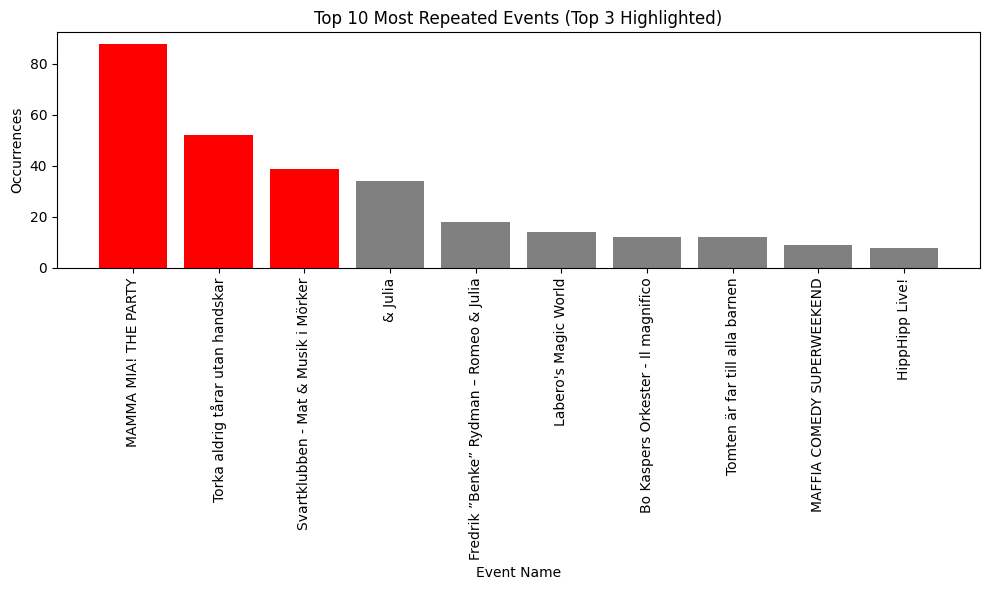

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data 
data = most_repeated_events.sort_values(by="occurrences", ascending=False)

# Top 3 events
top3 = data.head(3)["name"]

# Colors (highlight top 3)
colors = ["red" if name in top3.values else "grey"
          for name in data["name"]]

# Plot
ax.bar(data["name"], data["occurrences"], color=colors)

# Labels
ax.set_title("Top 10 Most Repeated Events (Top 3 Highlighted)")
ax.set_xlabel("Event Name")
ax.set_ylabel("Occurrences")
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Top venues by event volume(Top 10)

In [ ]:
top_venues_by_event_vol= con.execute("""
    SELECT venue_name, COUNT(*) AS total_events
    FROM events
    GROUP BY venue_name
    ORDER BY total_events DESC
    LIMIT 10;
    """).df()

top_venues_by_event_vol

,venue_name,total_events
0,Göta Lejon,95
1,Tyrol,90
2,Cirkus,89
3,Clarion Hotel Sign,51
4,Svartklubben,40
5,Dansens Hus - Stora Scen,33
6,Nya Cirkus,26
7,Strawberry Arena,25
8,Rival,22
9,Filadelfia Convention Center,20


## Visulization for top venues by venue

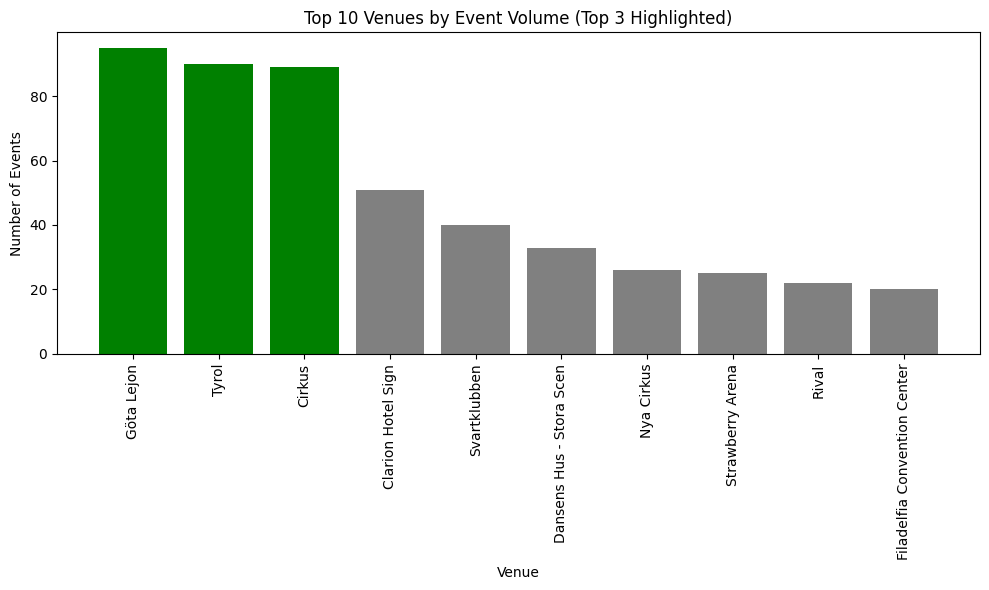

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data 
data = top_venues_by_event_vol.sort_values(by="total_events", ascending=False)

# Top 3 venues
top3 = data.head(3)["venue_name"]

# Colors (highlight top 3)
colors = ["green" if venue in top3.values else "grey"
          for venue in data["venue_name"]]

# Plot
ax.bar(data["venue_name"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 10 Venues by Event Volume (Top 3 Highlighted)")
ax.set_xlabel("Venue")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

## Events by day of week

In [ ]:
events_by_day_of_the_week= con.execute("""
    SELECT day_of_week, COUNT(*) AS total_events
    FROM events
    GROUP BY day_of_week
    ORDER BY total_events DESC;
    """).df()

events_by_day_of_the_week

,day_of_week,total_events
0,Saturday,246
1,Friday,145
2,Thursday,87
3,Sunday,52
4,Wednesday,45
5,Tuesday,34
6,Monday,24


## Events by month of the year 

In [ ]:
events_by_month_of_year= con.execute("""
    SELECT month_name, COUNT(*) AS total_events
    FROM events
    GROUP BY month_name
    ORDER BY total_events DESC;
    """).df()

events_by_month_of_year

,month_name,total_events
0,May,156
1,April,106
2,October,90
3,November,77
4,December,46
5,September,45
6,June,43
7,August,30
8,July,16
9,January,13


## Segment - Genre breakdown

In [ ]:
segment_genre= con.execute("""
    SELECT segment, genre, COUNT(*) AS total
    FROM events
    GROUP BY segment, genre
    ORDER BY total DESC;
    """).df()

segment_genre

,segment,genre,total
0,Arts & Theatre,Theatre,232
1,Arts & Theatre,Comedy,93
2,Arts & Theatre,Dance,65
3,Music,Rock,58
4,Music,Other,38
5,Miscellaneous,Food & Drink,30
6,Miscellaneous,Family,19
7,Music,Hip-Hop/Rap,19
8,Arts & Theatre,Spectacular,12
9,Arts & Theatre,Magic & Illusion,11


## Peak hours oveerall 

In [ ]:
overall_peak_hours= con.execute("""
    SELECT hour, COUNT(*) AS total_events
    FROM events
    GROUP BY hour
    ORDER BY hour;
    """).df()

overall_peak_hours

,hour,total_events
0,0,7
1,1,1
2,11,10
3,12,1
4,13,20
5,14,7
6,15,46
7,16,26
8,17,15
9,18,125


## Filter events(names) with their segments and genre that occur in Strawberry Arena

In [ ]:
events_in_strwb_arena=con.execute("""
   SELECT DISTINCT name, segment, genre
    FROM events
    WHERE venue_name = 'Strawberry Arena'
    """).df()

events_in_strwb_arena

,name,segment,genre
0,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Rock
1,Foo Fighters: TAKE COVER TOUR 2026 | Hotel Pac...,Music,Rock
2,The Weeknd: After Hours Til Dawn Tour | Strawb...,Music,Hip-Hop/Rap
3,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Latin
4,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour,Music,Latin
5,The Weeknd: After Hours Til Dawn Tour,Music,Other
6,Manchester United - Atlético De Madrid,Sports,Soccer
7,The Weeknd: After Hours Til Dawn Tour | VIP Pa...,Music,Hip-Hop/Rap
8,System Of A Down | Strawberry Arena Premium Ex...,Music,Metal
9,System Of A Down,Music,Rock


## Top 5 Genre 

In [ ]:
top_5_genres = con.execute("""
    SELECT genre, COUNT(*) AS total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    LIMIT 5;
""").df()


top_5_genres

,genre,total_events
0,Theatre,232
1,Comedy,93
2,Dance,65
3,Rock,58
4,Other,38


## Visualization for top genres 

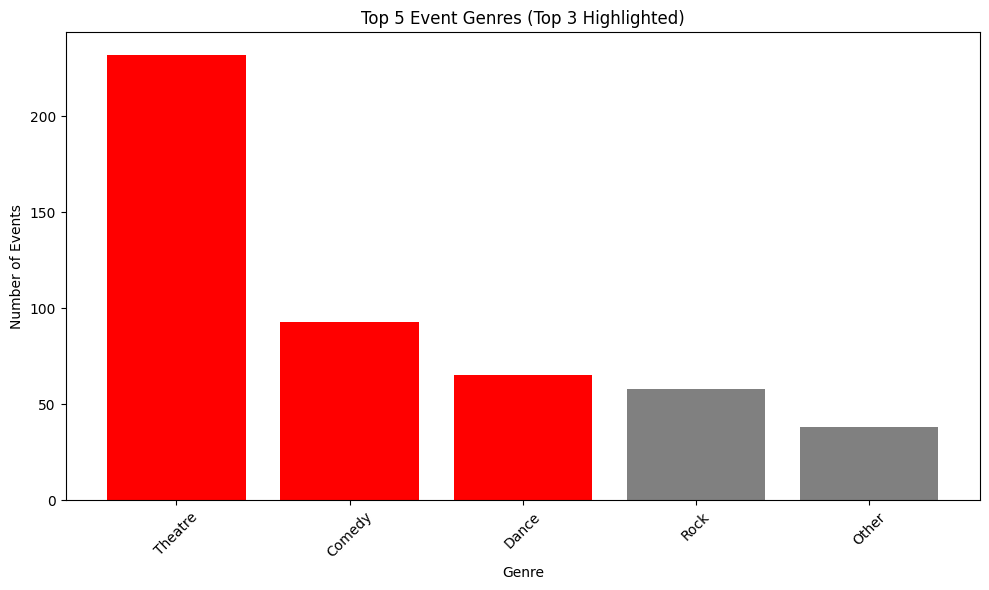

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data
data = top_5_genres.sort_values(by="total_events", ascending=False)

# Identify top 3
top3 = data.head(3)["genre"]

# Create colors
colors = ["red" if data in top3.values else "grey"
          for data in data["genre"]]

# Plot
ax.bar(data["genre"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 5 Event Genres (Top 3 Highlighted)")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

## Total number of events per month for the year 2026

In [ ]:
events_2026_monthly = con.execute("""
    SELECT 
        month_num,
        month_name,
        COUNT(*) AS total_events
    FROM events
    WHERE year = 2026
    GROUP BY month_num, month_name
    ORDER BY month_num;
""").df()

events_2026_monthly

,month_num,month_name,total_events
0,4,April,102
1,5,May,154
2,6,June,43
3,7,July,16
4,8,August,30
5,9,September,45
6,10,October,90
7,11,November,77
8,12,December,45


## Line chart for Visualization 

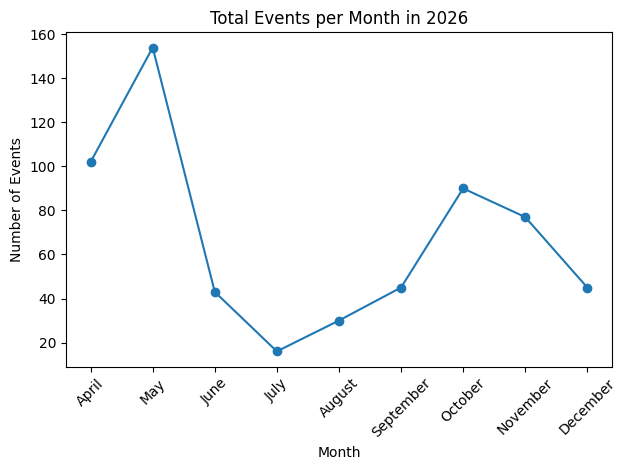

In [ ]:


fig, ax = plt.subplots()

ax.plot(
    events_2026_monthly["month_name"],
    events_2026_monthly["total_events"],
    marker="o"
)

ax.set_title("Total Events per Month in 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Events")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EDA for Museum Activities in Stockholm

In [6]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("api/data/stockholm_museums_complete.csv")

df.head()


,event_id,name,url,venue_name,venue_address,venue_city,venue_lat,venue_lon,rating,num_reviews,...,year,month_name,is_free,popularity_score,popularity_index,adult_price_sek,child_price_sek,free_age_range,student_price_sek,senior_price_sek
0,ChIJrymDbVSdX0YRQTLBtPGa8M8,Vasamuseet,https://www.vasamuseet.se/,Vasamuseet,"Galärvarvsvägen 14, 115 21 Stockholm, Sverige",Stockholm,59.328023,18.091396,4.8,66926,...,2026,All Year,False,1241.8,100.0,240.0,0.0,0–18,NaN,NaN
1,ChIJN5Ta_qqCX0YRMYVG1s-2NSw,Skansen,https://www.skansen.se/,Skansen,"Djurgårdsslätten 49-51, 115 21 Stockholm, Sverige",Stockholm,59.326323,18.105858,4.5,34496,...,2026,All Year,False,835.8,62.9,329.0,120.0,0–15,279.0,279.0
2,ChIJBf9B06qCX0YRR46XNXjwFUo,ABBA The Museum,https://www.abbathemuseum.com/,ABBA The Museum,"Djurgårdsvägen 68, 115 21 Stockholm, Sverige",Stockholm,59.325091,18.096781,4.5,20093,...,2026,All Year,False,637.9,44.8,329.0,120.0,0–6,279.0,279.0
3,ChIJhaN0M_l3X0YRpOq8uRb_RcA,Fotografiska Stockholm,https://stockholm.fotografiska.com/,Fotografiska Stockholm,"Stadsgårdshamnen 22, 116 45 Stockholm, Sverige",Stockholm,59.317962,18.084827,4.4,19504,...,2026,All Year,False,614.5,42.6,NaN,NaN,NaN,NaN,NaN
4,ChIJxagZg1OdX0YRGKnPhRyci9c,Nordiska museet,https://www.nordiskamuseet.se/,Nordiska museet,"Djurgårdsvägen 6-16, 115 93 Stockholm, Sverige",Stockholm,59.329008,18.094268,4.3,11098,...,2026,All Year,False,453.0,27.9,160.0,0.0,3–18,130.0,130.0


In [7]:
df.describe()

,venue_lat,venue_lon,rating,num_reviews,price_level,year,popularity_score,popularity_index,adult_price_sek,child_price_sek,student_price_sek,senior_price_sek
count,20.000000,20.000000,20.000000,20.000000,0.0,20.0,20.000000,20.000000,18.000000,18.000000,10.000000,11.000000
mean,59.331897,18.082953,4.445000,11320.800000,NaN,2026.0,408.575000,23.825000,186.111111,45.500000,162.700000,167.454545
std,0.011870,0.015764,0.176143,15422.255906,NaN,0.0,264.043774,24.142186,74.303740,68.670783,72.226573,67.997594
min,59.317962,18.053878,4.100000,1131.000000,NaN,2026.0,148.000000,0.000000,0.000000,0.000000,75.000000,75.000000
25%,59.326254,18.070844,4.300000,2706.750000,NaN,2026.0,227.425000,7.250000,160.000000,0.000000,116.250000,125.000000
50%,59.328773,18.083012,4.450000,7238.500000,NaN,2026.0,370.450000,20.350000,165.000000,0.000000,140.000000,150.000000
75%,59.333457,18.092389,4.500000,9715.750000,NaN,2026.0,428.625000,25.650000,229.000000,113.750000,200.500000,202.000000
max,59.368975,18.118803,4.800000,66926.000000,NaN,2026.0,1241.800000,100.000000,329.000000,195.000000,279.000000,279.000000


In [8]:
df.shape

(20, 26)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event_id           20 non-null     str    
 1   name               20 non-null     str    
 2   url                20 non-null     str    
 3   venue_name         20 non-null     str    
 4   venue_address      20 non-null     str    
 5   venue_city         20 non-null     str    
 6   venue_lat          20 non-null     float64
 7   venue_lon          20 non-null     float64
 8   rating             20 non-null     float64
 9   num_reviews        20 non-null     int64  
 10  price_level        0 non-null      float64
 11  opening_hours      20 non-null     str    
 12  status             20 non-null     str    
 13  segment            20 non-null     str    
 14  genre              20 non-null     str    
 15  subgenre           20 non-null     str    
 16  year               20 non-null     int6

In [11]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Top Attractions by Popularity

In [12]:
top_attractions = con.execute("""
    SELECT name, popularity_score
    FROM events
    ORDER BY popularity_score DESC
    LIMIT 5
""").df()

top_attractions

,name,popularity_score
0,Vasamuseet,1241.8
1,Skansen,835.8
2,ABBA The Museum,637.9
3,Fotografiska Stockholm,614.5
4,Nordiska museet,453.0


In [17]:
# Color definitons 

GRAY_1 = "#EAEAEA"
GRAY_2 = "#B0BEC5"
GRAY_3 = "#37474F"


BLUE = "#1E88E5"
GREEN = "#43A047"
RED = "#E53935"
ORANGE = "#FB8C00"
PURPLE = "#8E24AA"

## Visualization graph for top attractions by popularity 

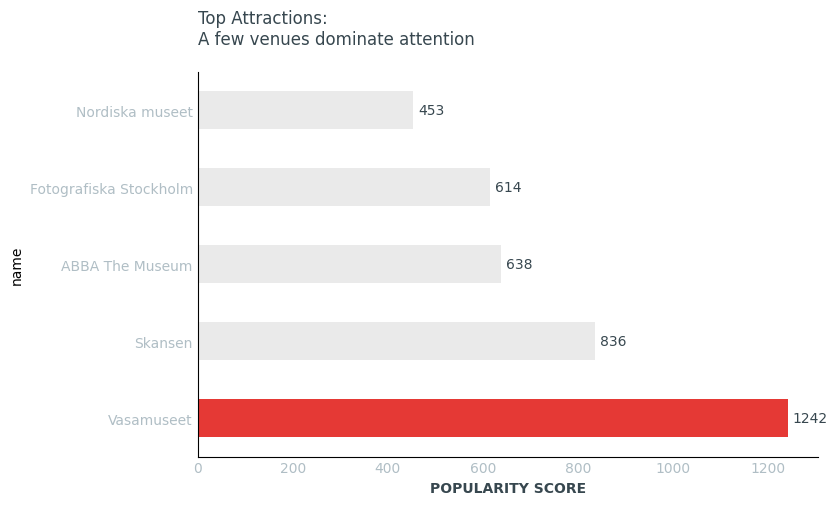

In [19]:
df_plot = top_attractions.sort_values("popularity_score")

colors = [GRAY_1]*len(df_plot)
colors[-1] = RED   

ax = df_plot.plot(
    kind="barh",
    x="name",
    y="popularity_score",
    figsize=(8,5),
    color=colors,
    legend=False
)

ax.spines[["top","right"]].set_visible(False)
ax.tick_params(axis="both", colors=GRAY_2, length=0)

ax.set_xlabel("POPULARITY SCORE", color=GRAY_3, fontweight="bold")

ax.set_title(
    "Top Attractions:\nA few venues dominate attention",
    loc="left",
    color=GRAY_3,
    pad=20
)

# labels
for i, v in enumerate(df_plot["popularity_score"]):
    ax.text(v + 10, i, f"{v:.0f}", va="center", color=GRAY_3)

ax.invert_yaxis()

## Free vs Paid Distribution 

In [14]:
free_vs_paid = con.execute("""
    SELECT is_free, COUNT(*) as total
    FROM events
    GROUP BY is_free
""").df()

free_vs_paid

,is_free,total
0,True,7
1,False,13


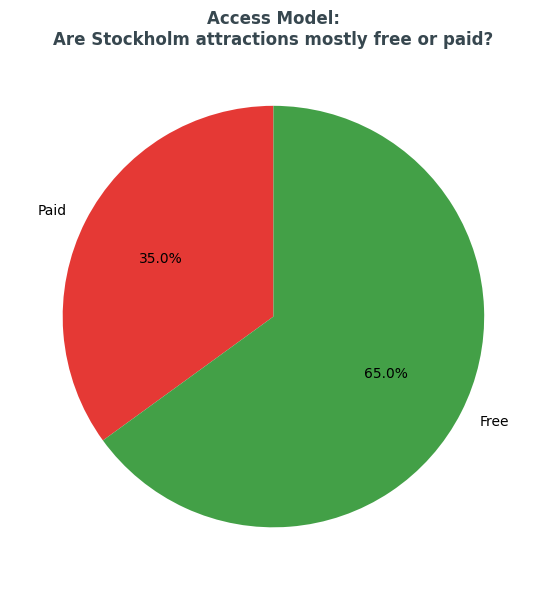

In [23]:
labels = ["Paid", "Free"] if False in free_vs_paid["is_free"].values else free_vs_paid["is_free"]

colors = [GREEN if val == False else RED for val in free_vs_paid["is_free"]]

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    free_vs_paid["total"],
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

ax.set_title(
    "Access Model:\nAre Stockholm attractions mostly free or paid?",
    color=GRAY_3,
    fontweight="bold"
)

plt.tight_layout()

## Top 5 Reviews (Social Power)

In [15]:
top_reviews = con.execute("""
    SELECT name, num_reviews
    FROM events
    ORDER BY num_reviews DESC
    LIMIT 5
""").df()

top_reviews

,name,num_reviews
0,Vasamuseet,66926
1,Skansen,34496
2,ABBA The Museum,20093
3,Fotografiska Stockholm,19504
4,Nordiska museet,11098


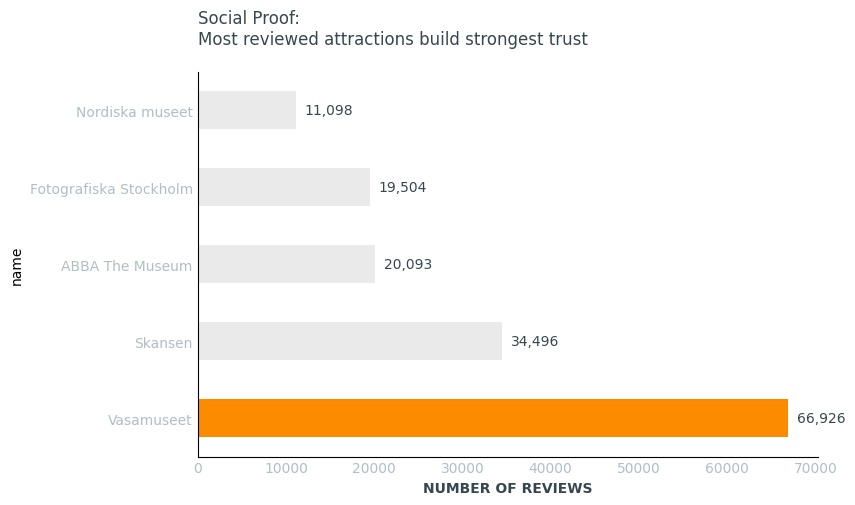

In [24]:
df_plot = top_reviews.sort_values("num_reviews")

colors = [GRAY_1]*len(df_plot)
colors[-1] = ORANGE   # highlight most reviewed

ax = df_plot.plot(
    kind="barh",
    x="name",
    y="num_reviews",
    figsize=(8,5),
    color=colors,
    legend=False
)

ax.spines[["top","right"]].set_visible(False)
ax.tick_params(axis="both", colors=GRAY_2, length=0)

ax.set_xlabel("NUMBER OF REVIEWS", color=GRAY_3, fontweight="bold")

ax.set_title(
    "Social Proof:\nMost reviewed attractions build strongest trust",
    loc="left",
    color=GRAY_3,
    pad=20
)

# labels
for i, v in enumerate(df_plot["num_reviews"]):
    ax.text(v + 1000, i, f"{int(v):,}", va="center", color=GRAY_3)

ax.invert_yaxis()